/tmp/ipykernel_45975/2239522387.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


Epoch 1/2000, Train Loss: 0.1337, Val Loss: 0.0825
Epoch 2/2000, Train Loss: 0.0702, Val Loss: 0.0575
Epoch 3/2000, Train Loss: 0.0568, Val Loss: 0.0491
Epoch 4/2000, Train Loss: 0.0499, Val Loss: 0.0463
Epoch 5/2000, Train Loss: 0.0426, Val Loss: 0.0433
Epoch 6/2000, Train Loss: 0.0398, Val Loss: 0.0366
Epoch 7/2000, Train Loss: 0.0377, Val Loss: 0.0335
Epoch 8/2000, Train Loss: 0.0352, Val Loss: 0.0301
Epoch 9/2000, Train Loss: 0.0264, Val Loss: 0.0269
Epoch 10/2000, Train Loss: 0.0244, Val Loss: 0.0248
Epoch 11/2000, Train Loss: 0.0219, Val Loss: 0.0232
Epoch 12/2000, Train Loss: 0.0211, Val Loss: 0.0224
Epoch 13/2000, Train Loss: 0.0201, Val Loss: 0.0219
Epoch 14/2000, Train Loss: 0.0246, Val Loss: 0.0208
Epoch 15/2000, Train Loss: 0.0199, Val Loss: 0.0191
Epoch 16/2000, Train Loss: 0.0187, Val Loss: 0.0180
Epoch 17/2000, Train Loss: 0.0163, Val Loss: 0.0173
Epoch 18/2000, Train Loss: 0.0156, Val Loss: 0.0165
Epoch 19/2000, Train Loss: 0.0185, Val Loss: 0.0152
Epoch 20/2000, Train 

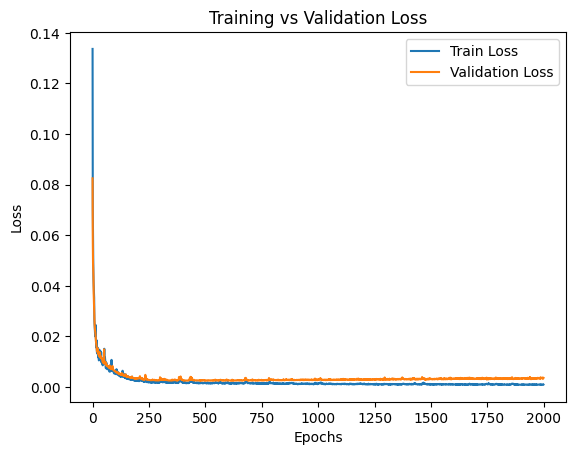

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
import pandas as pd
import shutil

# Custom Dataset Loader for Unlabeled TIFF Images
class UnlabeledTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, fname) for fname in os.listdir(root_dir) if fname.lower().endswith(('tif', 'tiff'))]
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = tiff.imread(img_path).astype(np.float32)   
            image = image * 240
            image[image>254]=254
            if image.ndim == 3:
                image = image[0]
        except Exception as e:
            print(f"Warning: Skipping unreadable image {img_path} - {e}")
            return self.__getitem__((idx + 1) % len(self.image_paths))
        


        # Convert NumPy array to PIL Image
        image = Image.fromarray((image).astype(np.uint8))  # Convert to 8-bit grayscale
        
        if self.transform:
            image = self.transform(image)
        
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        
        image = image.squeeze(1)
        return image, 0

# Step 1: Define the Autoencoder (VAE)
class VAE(nn.Module):
    def __init__(self, latent_dim=8):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        x = self.encoder(x)
        mu, logvar = self.fc_mu(x), self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        x = self.fc_decode(z).view(-1, 128, 8, 8)
        return self.decoder(x), mu, logvar

# Step 2: Train Autoencoder and Extract Latent Representations
def train_vae(model, train_loader, val_loader, epochs=2000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss = loss_fn(recon, x) + 0.1 * (mu.pow(2).mean() + logvar.exp().mean())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                loss = loss_fn(recon, x) + 0.1 * (mu.pow(2).mean() + logvar.exp().mean())
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Plot training and validation loss
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()
    
    return model


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/normed_circle_tiffs"
os.makedirs(data_dir,exist_ok=True)

# Load CSV
data_csv = "/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_mt_strcture_20250310_MA.csv"
image_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results/Microtubule_GUV-Liu-20250106T211105Z-001/processed_GUV_MT/from_annotation_to_circle_square_edge/MT_square_image"

df = pd.read_csv(data_csv)

for index, row in df.iterrows():
    index_select = int(row['filename'][-8:-4])
    
    if index_select not in [18,21,328,480,356,543,669,78,242,726,762,771,812,977,983]:
        shutil.copyfile(os.path.join(image_dir,row['filename'].replace('png','tif')),
                        os.path.join(data_dir,row['filename'].replace('png','tif')))


transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images from 96x96 → 64x64
    transforms.ToTensor()
])
dataset = UnlabeledTIFFDataset(root_dir=data_dir, transform=transform)

# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Train VAE
vae = VAE().to(device)
vae = train_vae(vae, train_loader, val_loader)


In [2]:

# Step 3: Cluster in 32D Latent Space
def cluster_latents(model, dataloader, num_clusters=5):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, mu, _ = model(x)
            latents.append(mu.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)
    
    # Apply K-Means clustering in 32D latent space
    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(latents)
    labels = kmeans.labels_
    return latents, labels, images

# Step 4: Visualize Clusters with t-SNE and Reconstructed Images
def visualize_clusters(latents, labels, images, model):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    latents_2d = tsne.fit_transform(latents)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7,s=0.5)    
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title("2D Visualization of Latent Space using t-SNE")
    plt.show()
    
    # Select one image per cluster
    selected_images = []
    selected_labels = set()
    for i, label in enumerate(labels):
        if label not in selected_labels:
            selected_labels.add(label)
            selected_images.append(images[i])
        if len(selected_labels) == 5:
            break
    
    selected_images = torch.stack(selected_images).to(device)
    reconstructed, _, _ = model(selected_images)
    
    # Display original and reconstructed images
    fig, axes = plt.subplots(2, len(selected_images), figsize=(15, 5))
    for i in range(len(selected_images)):
        axes[0, i].imshow(selected_images[i].squeeze().cpu(), cmap='gray', vmax=1.0,vmin=0)
        axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray', vmax=1.0,vmin=0)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    plt.show()

In [3]:
def cluster_and_display_images(vae, dataloader, num_clusters=5):
    vae.eval()
    latents, images = [], []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, mu, _ = vae(x)
            latents.append(mu.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)
    
    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(latents)
    labels = kmeans.labels_
    
    # Select 10 images per cluster for visualization
    num_images_per_cluster = 6
    selected_images, selected_reconstructions = [], []
    for cluster_id in range(num_clusters):
        indices = np.where(labels == cluster_id)[0][:num_images_per_cluster]
        selected_images.append(images[indices])
    selected_images = torch.cat(selected_images).to(device)
    
    # Generate reconstructions
    with torch.no_grad():
        reconstructions, _, _ = vae(selected_images)
    
    # Display images in 8x10 grid (10 images per cluster, original vs reconstructed)
    fig, axes = plt.subplots(num_clusters, num_images_per_cluster, figsize=(15, num_clusters * 2))
    for i in range(num_clusters):
        for j in range(num_images_per_cluster):
            axes[i, j].imshow(selected_images[i * num_images_per_cluster + j].squeeze().cpu(), cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f"C{i+1}") if j == 0 else None
    
    plt.show()
    
    fig, axes = plt.subplots(num_clusters, num_images_per_cluster, figsize=(15, num_clusters * 2))
    for i in range(num_clusters):
        for j in range(num_images_per_cluster):
            axes[i, j].imshow(reconstructions[i * num_images_per_cluster + j].squeeze().cpu(), cmap='gray')
            axes[i, j].axis('off')
    
    plt.show()

    visualize_clusters(latents, labels, images, vae)

/tmp/ipykernel_45975/2239522387.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


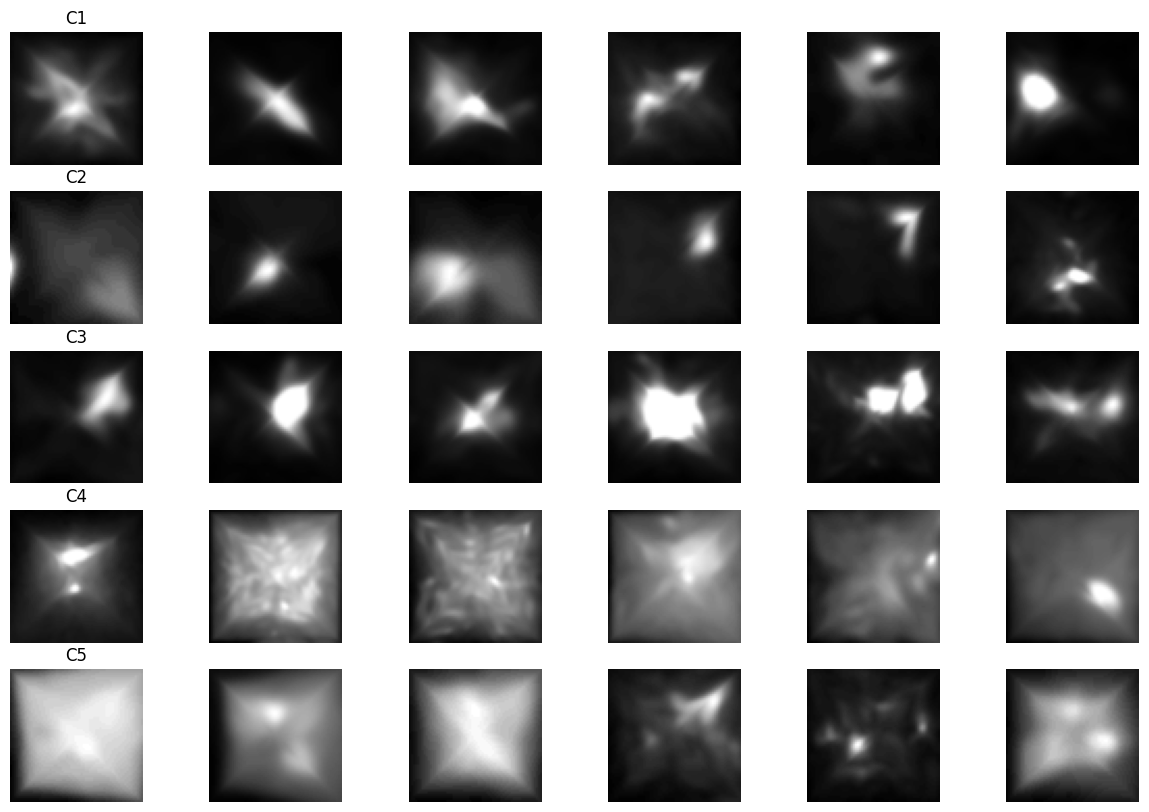

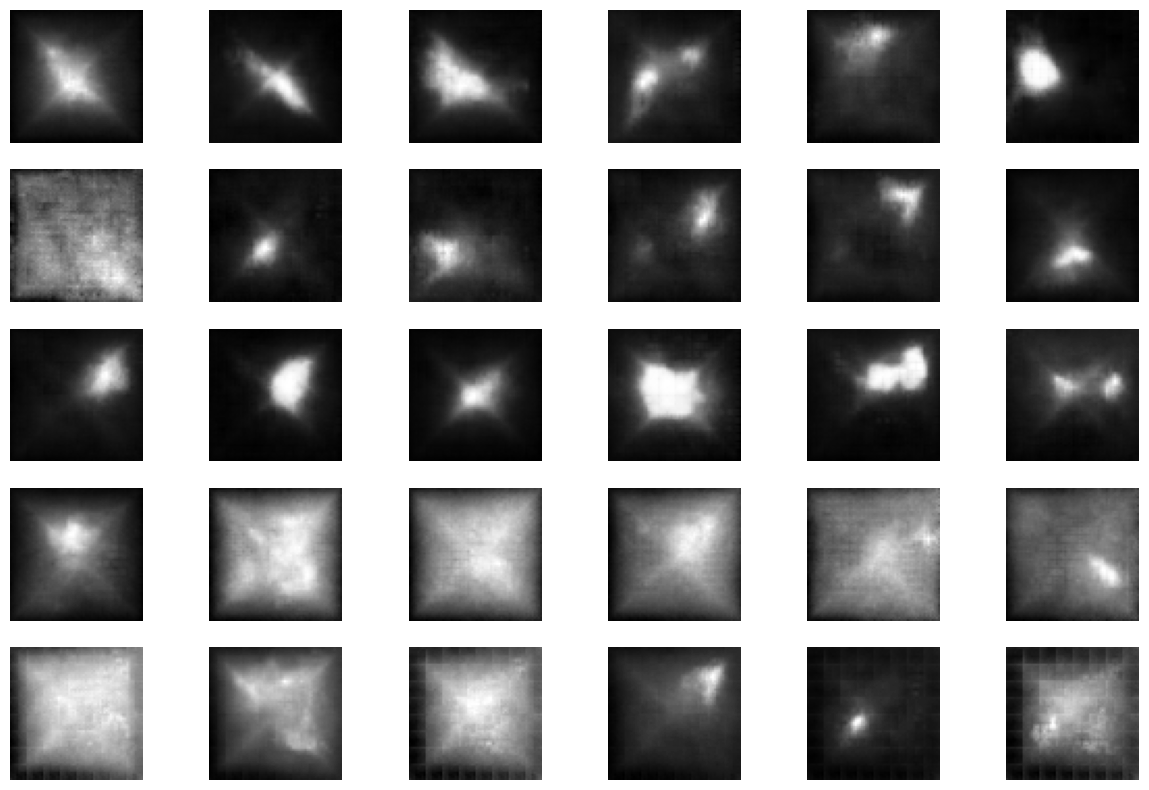

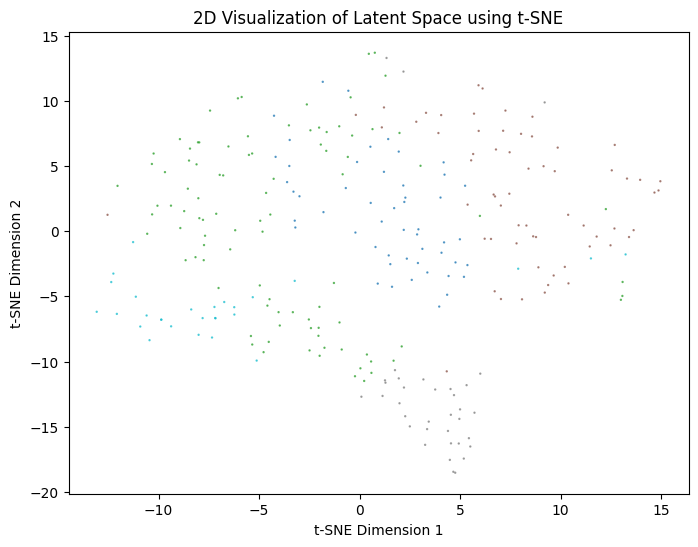

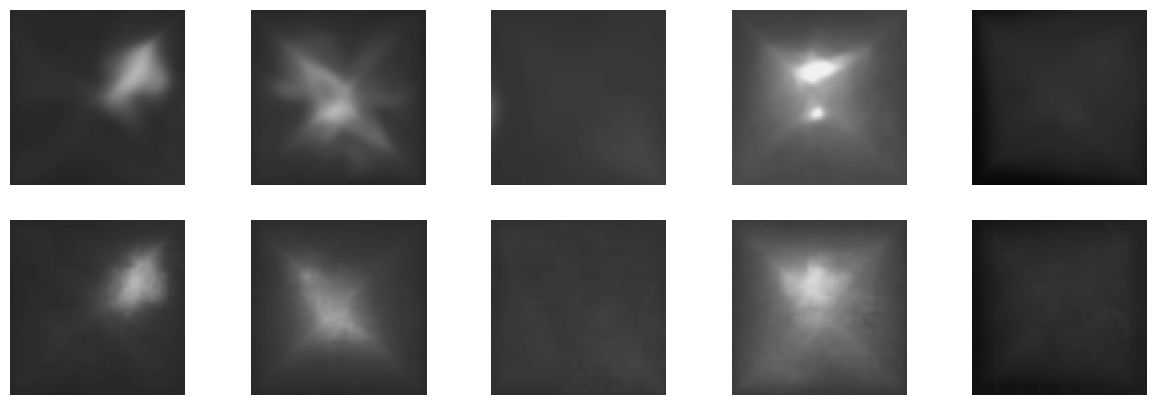

In [4]:
# Perform clustering and display images
cluster_and_display_images(vae, train_loader,num_clusters=5)


In [ ]:
import numpy as np
from scipy.ndimage import map_coordinates

def disk_to_square(image, cx, cy, r, output_size=128):
    """
    Warp a circular region (disk) into a square of shape (output_size, output_size)
    """
    image = image.astype(np.float32)
    
    # Create normalized square grid: x, y ∈ [-1, 1]
    lin = np.linspace(-1, 1, output_size)
    xv, yv = np.meshgrid(lin, lin)

    # Map square to disk using a conformal mapping (polar-style)
    r_norm = np.sqrt(xv**2 + yv**2)
    theta = np.arctan2(yv, xv)

    # Normalized radial stretch: remap square → disk
    denominator = np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
    denominator[denominator == 0] = 1e-6  # avoid divide by zero
    x_disk = (r_norm * denominator) * np.cos(theta)
    y_disk = (r_norm * denominator) * np.sin(theta)

    # Scale and shift to actual image coordinates
    x_mapped = cx + x_disk * r
    y_mapped = cy + y_disk * r

    # Sample from image
    coords = np.vstack([y_mapped.ravel(), x_mapped.ravel()])
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)

    # Reshape and mask
    square = sampled.reshape((output_size, output_size))    

    edge_intensity = np.concatenate([square[0, :], square[-1, :]])
    edge_intensity = edge_intensity[edge_intensity > 0]

    fill_value = np.mean(edge_intensity) if edge_intensity.size > 0 else 0
    square[square == 0] = fill_value

    return square


In [ ]:
import numpy as np
from scipy.ndimage import map_coordinates

def square_to_disk(image, cx, cy, r, output_size=128):
    """
    Warp a circular region (disk) into a square of shape (output_size, output_size)
    """
    image = image.astype(np.float32)
    
    # Create normalized square grid: x, y ∈ [-1, 1]
    lin = np.linspace(-1, 1, output_size)
    xv, yv = np.meshgrid(lin, lin)

    # Map square to disk using a conformal mapping (polar-style)
    r_norm = np.sqrt(xv**2 + yv**2)
    theta = np.arctan2(yv, xv)

    # Normalized radial stretch: remap square → disk
    denominator = np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
    denominator[denominator == 0] = 1e-6  # avoid divide by zero
    x_disk = (r_norm / denominator) * np.cos(theta)
    y_disk = (r_norm / denominator) * np.sin(theta)

    # Scale and shift to actual image coordinates
    x_mapped = cx + x_disk * r
    y_mapped = cy + y_disk * r

    # Sample from image
    coords = np.vstack([y_mapped.ravel(), x_mapped.ravel()])
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)

    # Reshape and mask
    square = sampled.reshape((output_size, output_size))    

    # edge_intensity = np.concatenate([square[0, :], square[-1, :]])
    # edge_intensity = edge_intensity[edge_intensity > 0]

    # fill_value = np.mean(edge_intensity) if edge_intensity.size > 0 else 0
    # square[square == 0] = fill_value

    return square


In [ ]:


square_to_disk(image, 64, 64, 64, output_size=128)